
# MARL Assignment Extension — Corrected Version

This notebook rewrites the extension so it matches the new question paper more closely:

1. **Task 1:** Re-implements the *same three Assignment 1 problems* using **SARSA** and **n-step SARSA**, then compares performance as `n` increases.
2. **Task 2:** Re-implements **Assignment 1, Question 1** using **Q-learning**.
3. **Task 3:** Compares the original model-based / Monte Carlo methods with the new TD methods.
4. **Task 4:** Uses a **proxy benchmark** to choose a scalable method, then applies the chosen method to a **1000×1000 grid** with 10% obstacles.

The uploaded question paper clearly contains **three original problems** in Assignment 1, not just one, so Task 1 is interpreted in that broader sense.  
See: Question 1, Question 2, and Question 3 in the PDF. fileciteturn5file0L9-L80 fileciteturn5file1L40-L72


In [1]:

import math
import time
import random
from dataclasses import dataclass
from collections import defaultdict, deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ------------------------------------------------------------------
# Global controls
# ------------------------------------------------------------------
SEED = 7
FAST_MODE = True   # keep True for presentation-safe runs; set False for deeper training

random.seed(SEED)
np.random.seed(SEED)

if FAST_MODE:
    CFG = {
        'q1_episodes': 1200,
        'q2_episodes': 1400,
        'q3_episodes': 1600,
        'mc_episodes_small': 800,
        'task4_proxy_episodes': 1000,
        'task4_finetune_episodes': 120,
        'eval_episodes': 120,
        'max_steps_small': 200,
        'max_steps_large': 5000,
    }
else:
    CFG = {
        'q1_episodes': 4000,
        'q2_episodes': 5000,
        'q3_episodes': 6000,
        'mc_episodes_small': 3000,
        'task4_proxy_episodes': 3000,
        'task4_finetune_episodes': 300,
        'eval_episodes': 250,
        'max_steps_small': 300,
        'max_steps_large': 8000,
    }

print('FAST_MODE =', FAST_MODE)
print(CFG)


FAST_MODE = True
{'q1_episodes': 1200, 'q2_episodes': 1400, 'q3_episodes': 1600, 'mc_episodes_small': 800, 'task4_proxy_episodes': 1000, 'task4_finetune_episodes': 120, 'eval_episodes': 120, 'max_steps_small': 200, 'max_steps_large': 5000}


## Shared helper functions

In [2]:

# ------------------------------------------------------------------
# Shared helper functions
# ------------------------------------------------------------------

def make_rng(seed=None):
    return random.Random(SEED if seed is None else seed)


def epsilon_greedy(q_values, epsilon, rng):
    if rng.random() < epsilon:
        return rng.randrange(len(q_values))
    best = np.max(q_values)
    best_actions = [a for a, v in enumerate(q_values) if v == best]
    return rng.choice(best_actions)


def moving_average(values, window=50):
    if len(values) == 0:
        return np.array([])
    window = max(1, min(window, len(values)))
    kernel = np.ones(window) / window
    return np.convolve(np.asarray(values, dtype=float), kernel, mode='valid')


def plot_learning_curves(curve_dict, title, ylabel='Return', window=50):
    plt.figure(figsize=(9, 4))
    for name, values in curve_dict.items():
        ma = moving_average(values, window=window)
        if len(ma) == 0:
            continue
        xs = np.arange(len(ma)) + window
        plt.plot(xs, ma, label=name)
    plt.title(title)
    plt.xlabel('Episode')
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def greedy_policy_from_q(Q):
    policy = {}
    for s, q in Q.items():
        policy[s] = int(np.argmax(q))
    return policy


def evaluate_policy(env, policy=None, Q=None, episodes=100, max_steps=200, seed=123):
    rng = make_rng(seed)
    returns = []
    successes = 0
    lengths = []

    for _ in range(episodes):
        state = env.reset(rng)
        done = False
        total = 0.0
        steps = 0
        while not done and steps < max_steps:
            if Q is not None:
                q_values = Q[state]
                action = int(np.argmax(q_values))
            else:
                action = policy.get(state, 0)
            next_state, reward, done, info = env.step(state, action, rng)
            total += reward
            state = next_state
            steps += 1
        returns.append(total)
        lengths.append(steps)
        if info.get('success', False):
            successes += 1

    return {
        'avg_return': float(np.mean(returns)),
        'success_rate': float(successes / episodes),
        'avg_steps': float(np.mean(lengths))
    }


def summarize_results(rows, title='Results Summary'):
    df = pd.DataFrame(rows)
    if len(df) == 0:
        return df
    print(title)
    display(df)
    return df


## Generic finite-MDP solvers and TD control

In [3]:

# ------------------------------------------------------------------
# Generic finite-MDP solvers (for the small assignment environments)
# ------------------------------------------------------------------

def value_iteration(env, gamma=0.95, theta=1e-6, max_iters=500):
    V = {s: 0.0 for s in env.states}
    deltas = []
    start = time.time()

    for _ in range(max_iters):
        delta = 0.0
        newV = dict(V)
        for s in env.states:
            best = -1e18
            best_a = 0
            for a in range(env.n_actions):
                q = 0.0
                for p, ns, r, done in env.model_transitions(s, a):
                    q += p * (r if done else (r + gamma * V[ns]))
                if q > best:
                    best = q
                    best_a = a
            newV[s] = best
            delta = max(delta, abs(best - V[s]))
        V = newV
        deltas.append(delta)
        if delta < theta:
            break

    policy = {}
    for s in env.states:
        best = -1e18
        best_a = 0
        for a in range(env.n_actions):
            q = 0.0
            for p, ns, r, done in env.model_transitions(s, a):
                q += p * (r if done else (r + gamma * V[ns]))
            if q > best:
                best = q
                best_a = a
        policy[s] = best_a
    return V, policy, deltas, time.time() - start


def policy_iteration(env, gamma=0.95, theta=1e-6, max_policy_iters=80, max_eval_iters=500):
    rng = make_rng(999)
    policy = {s: rng.randrange(env.n_actions) for s in env.states}
    V = {s: 0.0 for s in env.states}
    start = time.time()
    stable_iter = 0

    for it in range(max_policy_iters):
        # policy evaluation
        for _ in range(max_eval_iters):
            delta = 0.0
            newV = dict(V)
            for s in env.states:
                a = policy[s]
                v = 0.0
                for p, ns, r, done in env.model_transitions(s, a):
                    v += p * (r if done else (r + gamma * V[ns]))
                newV[s] = v
                delta = max(delta, abs(v - V[s]))
            V = newV
            if delta < theta:
                break

        stable = True
        for s in env.states:
            old = policy[s]
            best = -1e18
            best_a = old
            for a in range(env.n_actions):
                q = 0.0
                for p, ns, r, done in env.model_transitions(s, a):
                    q += p * (r if done else (r + gamma * V[ns]))
                if q > best:
                    best = q
                    best_a = a
            policy[s] = best_a
            if best_a != old:
                stable = False
        stable_iter = it + 1
        if stable:
            break

    return V, policy, stable_iter, time.time() - start


# ------------------------------------------------------------------
# Generic model-free control
# ------------------------------------------------------------------

def train_sarsa(env, episodes, alpha=0.1, gamma=0.95, epsilon=0.2,
                epsilon_decay=0.995, min_epsilon=0.02, max_steps=200, seed=123):
    rng = make_rng(seed)
    Q = defaultdict(lambda: np.zeros(env.n_actions, dtype=float))
    returns = []

    eps = epsilon
    start_time = time.time()
    for ep in range(episodes):
        s = env.reset(rng)
        a = epsilon_greedy(Q[s], eps, rng)
        total = 0.0
        done = False
        steps = 0

        while not done and steps < max_steps:
            ns, r, done, info = env.step(s, a, rng)
            total += r
            if done:
                target = r
                Q[s][a] += alpha * (target - Q[s][a])
            else:
                na = epsilon_greedy(Q[ns], eps, rng)
                target = r + gamma * Q[ns][na]
                Q[s][a] += alpha * (target - Q[s][a])
                s, a = ns, na
            steps += 1
        returns.append(total)
        eps = max(min_epsilon, eps * epsilon_decay)

    return {
        'Q': Q,
        'returns': returns,
        'time': time.time() - start_time,
        'policy': greedy_policy_from_q(Q)
    }


def train_q_learning(env, episodes, alpha=0.1, gamma=0.95, epsilon=0.2,
                     epsilon_decay=0.995, min_epsilon=0.02, max_steps=200, seed=123):
    rng = make_rng(seed)
    Q = defaultdict(lambda: np.zeros(env.n_actions, dtype=float))
    returns = []

    eps = epsilon
    start_time = time.time()
    for ep in range(episodes):
        s = env.reset(rng)
        total = 0.0
        done = False
        steps = 0
        while not done and steps < max_steps:
            a = epsilon_greedy(Q[s], eps, rng)
            ns, r, done, info = env.step(s, a, rng)
            total += r
            best_next = 0.0 if done else np.max(Q[ns])
            target = r + gamma * best_next
            Q[s][a] += alpha * (target - Q[s][a])
            s = ns
            steps += 1
        returns.append(total)
        eps = max(min_epsilon, eps * epsilon_decay)

    return {
        'Q': Q,
        'returns': returns,
        'time': time.time() - start_time,
        'policy': greedy_policy_from_q(Q)
    }


def train_n_step_sarsa(env, n, episodes, alpha=0.1, gamma=0.95, epsilon=0.2,
                       epsilon_decay=0.995, min_epsilon=0.02, max_steps=200, seed=123):
    rng = make_rng(seed)
    Q = defaultdict(lambda: np.zeros(env.n_actions, dtype=float))
    returns = []
    eps = epsilon
    start_time = time.time()

    for ep in range(episodes):
        S = []
        A = []
        R = [0.0]

        s0 = env.reset(rng)
        a0 = epsilon_greedy(Q[s0], eps, rng)
        S.append(s0)
        A.append(a0)

        T = float('inf')
        t = 0
        total = 0.0
        info = {'success': False}

        while True:
            if t < T:
                st = S[t]
                at = A[t]
                ns, r, done, info = env.step(st, at, rng)
                total += r
                R.append(r)
                if done or t + 1 >= max_steps:
                    T = t + 1
                else:
                    S.append(ns)
                    na = epsilon_greedy(Q[ns], eps, rng)
                    A.append(na)

            tau = t - n + 1
            if tau >= 0:
                G = 0.0
                upper = (tau + n) if T == float('inf') else min(tau + n, int(T))
                for i in range(tau + 1, upper + 1):
                    G += (gamma ** (i - tau - 1)) * R[i]
                if T == float('inf') or tau + n < T:
                    G += (gamma ** n) * Q[S[tau + n]][A[tau + n]]
                Q[S[tau]][A[tau]] += alpha * (G - Q[S[tau]][A[tau]])

            if tau == T - 1:
                break
            t += 1

        returns.append(total)
        eps = max(min_epsilon, eps * epsilon_decay)

    return {
        'Q': Q,
        'returns': returns,
        'time': time.time() - start_time,
        'policy': greedy_policy_from_q(Q)
    }


def monte_carlo_control(env, episodes, gamma=0.95, epsilon=0.2, max_steps=200, seed=123):
    rng = make_rng(seed)
    Q = defaultdict(lambda: np.zeros(env.n_actions, dtype=float))
    returns_sum = defaultdict(float)
    returns_count = defaultdict(int)
    curve = []
    eps = epsilon
    start = time.time()

    for ep in range(episodes):
        s = env.reset(rng)
        episode = []
        total = 0.0
        done = False
        steps = 0
        while not done and steps < max_steps:
            a = epsilon_greedy(Q[s], eps, rng)
            ns, r, done, info = env.step(s, a, rng)
            episode.append((s, a, r))
            total += r
            s = ns
            steps += 1

        G = 0.0
        visited = set()
        for t in range(len(episode) - 1, -1, -1):
            s, a, r = episode[t]
            G = gamma * G + r
            key = (s, a)
            if key not in visited:
                visited.add(key)
                returns_sum[key] += G
                returns_count[key] += 1
                Q[s][a] = returns_sum[key] / returns_count[key]
        curve.append(total)
        eps = max(0.02, eps * 0.999)

    return {
        'Q': Q,
        'returns': curve,
        'time': time.time() - start,
        'policy': greedy_policy_from_q(Q)
    }


## Assignment 1 — Question 1 environment (orientation-aware differential drive)

Q1 states = 376  | obstacles = [(3, 2), (7, 7), (7, 8), (8, 7), (8, 9)]


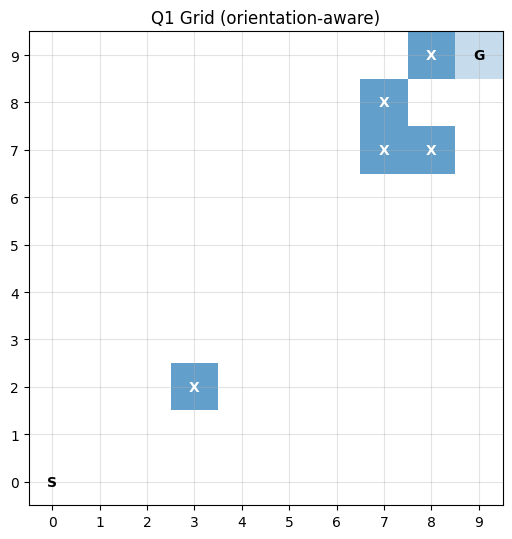

In [4]:

# ------------------------------------------------------------------
# Q1: Differential-drive robot with orientation-aware planning
# ------------------------------------------------------------------

class OrientationGridEnv:
    ACTIONS = ['Forward', 'TurnLeft', 'TurnRight']
    DIRS = {
        0: (1, 0),   # East
        1: (0, 1),   # North
        2: (-1, 0),  # West
        3: (0, -1)   # South
    }

    def __init__(self, rows=10, cols=10, seed=11):
        self.rows = rows
        self.cols = cols
        self.n_actions = 3
        self.gamma_default = 0.95
        self.step_reward = -1
        self.collision_reward = -100
        self.goal_reward = 50
        self.goal = (rows - 1, cols - 1)
        self.rng_setup = make_rng(seed)

        protected = {(0, 0), self.goal}
        self.obstacles = set()
        while len(self.obstacles) < 5:
            x = self.rng_setup.randrange(self.cols)
            y = self.rng_setup.randrange(self.rows)
            if (x, y) not in protected:
                self.obstacles.add((x, y))

        self.states = []
        for x in range(self.cols):
            for y in range(self.rows):
                if (x, y) in self.obstacles or (x, y) == self.goal:
                    continue
                for o in range(4):
                    self.states.append((x, y, o))

        self.start_state = (0, 0, 0)
        self.valid_starts = list(self.states)

    def in_bounds(self, x, y):
        return 0 <= x < self.cols and 0 <= y < self.rows and (x, y) not in self.obstacles

    def random_start(self, rng):
        return rng.choice(self.valid_starts)

    def reset(self, rng):
        # Random starts make TD / MC fairer on this large state space
        return self.random_start(rng)

    def _forward_targets(self, x, y, o):
        dx, dy = self.DIRS[o]
        left_o = (o + 1) % 4
        right_o = (o - 1) % 4
        ldx, ldy = self.DIRS[left_o]
        rdx, rdy = self.DIRS[right_o]
        return [
            (0.8, x + dx, y + dy, o),
            (0.1, x + ldx, y + ldy, o),
            (0.1, x + rdx, y + rdy, o),
        ]

    def model_transitions(self, state, action):
        x, y, o = state
        if action == 1:  # TurnLeft
            return [(1.0, (x, y, (o + 1) % 4), self.step_reward, False)]
        if action == 2:  # TurnRight
            return [(1.0, (x, y, (o - 1) % 4), self.step_reward, False)]

        out = []
        for p, nx, ny, no in self._forward_targets(x, y, o):
            if not self.in_bounds(nx, ny):
                out.append((p, state, self.collision_reward, True))
            elif (nx, ny) == self.goal:
                out.append((p, (nx, ny, no), self.goal_reward, True))
            else:
                out.append((p, (nx, ny, no), self.step_reward, False))
        return out

    def step(self, state, action, rng):
        trans = self.model_transitions(state, action)
        probs = [p for p, *_ in trans]
        idx = rng.choices(range(len(trans)), weights=probs, k=1)[0]
        p, ns, r, done = trans[idx]
        info = {'success': done and r == self.goal_reward}
        return ns, r, done, info

    def draw_grid(self):
        plt.figure(figsize=(5.5, 5.5))
        ax = plt.gca()
        ax.set_xlim(-0.5, self.cols - 0.5)
        ax.set_ylim(-0.5, self.rows - 0.5)
        ax.set_xticks(range(self.cols))
        ax.set_yticks(range(self.rows))
        ax.grid(True, alpha=0.35)
        for (x, y) in self.obstacles:
            ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, alpha=0.7))
            ax.text(x, y, 'X', ha='center', va='center', color='white', fontweight='bold')
        gx, gy = self.goal
        ax.add_patch(plt.Rectangle((gx - 0.5, gy - 0.5), 1, 1, alpha=0.25))
        ax.text(gx, gy, 'G', ha='center', va='center', fontweight='bold')
        ax.text(0, 0, 'S', ha='center', va='center', fontweight='bold')
        ax.set_title('Q1 Grid (orientation-aware)')
        ax.set_aspect('equal')
        plt.tight_layout()
        plt.show()


q1_env = OrientationGridEnv()
print('Q1 states =', len(q1_env.states), ' | obstacles =', sorted(q1_env.obstacles))
q1_env.draw_grid()


## Assignment 1 — Question 2 environment (battery-aware navigation)

Q2 states = 943  | obstacles = [(0, 8), (1, 8), (3, 6), (4, 9), (5, 8)] | chargers = [(3, 3), (5, 7), (7, 2)]


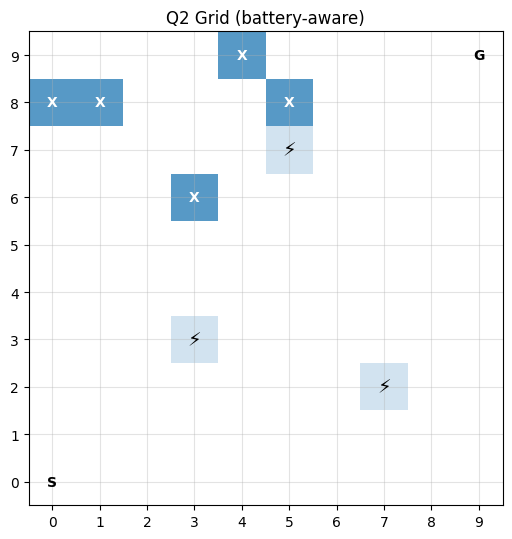

In [5]:

# ------------------------------------------------------------------
# Q2: Battery-aware robot navigation
# ------------------------------------------------------------------

class BatteryGridEnv:
    ACTIONS = ['Up', 'Down', 'Left', 'Right', 'Recharge']
    MOVES = {
        0: (0, 1),
        1: (0, -1),
        2: (-1, 0),
        3: (1, 0),
    }

    def __init__(self, rows=10, cols=10, max_battery=10, seed=19):
        self.rows = rows
        self.cols = cols
        self.max_battery = max_battery
        self.n_actions = 5
        self.gamma_default = 0.95
        self.move_reward = -1
        self.recharge_reward = -2
        self.dead_reward = -100
        self.goal_reward = 100
        self.goal = (rows - 1, cols - 1)
        self.start_state = (0, 0, max_battery)
        self.charging = {(3, 3), (7, 2), (5, 7)}
        self.rng_setup = make_rng(seed)

        protected = {(0, 0), self.goal} | set(self.charging)
        self.obstacles = set()
        while len(self.obstacles) < 5:
            x = self.rng_setup.randrange(self.cols)
            y = self.rng_setup.randrange(self.rows)
            if (x, y) not in protected:
                self.obstacles.add((x, y))

        self.states = []
        for x in range(self.cols):
            for y in range(self.rows):
                if (x, y) in self.obstacles or (x, y) == self.goal:
                    continue
                for b in range(self.max_battery + 1):
                    if b == 0 and (x, y) not in self.charging:
                        continue
                    self.states.append((x, y, b))

    def in_bounds(self, x, y):
        return 0 <= x < self.cols and 0 <= y < self.rows and (x, y) not in self.obstacles

    def reset(self, rng):
        return self.start_state

    def model_transitions(self, state, action):
        x, y, b = state

        if action == 4:  # recharge
            if (x, y) in self.charging:
                return [(1.0, (x, y, self.max_battery), self.recharge_reward, False)]
            return [(1.0, state, self.move_reward, False)]

        if b == 0 and (x, y) not in self.charging:
            # not normally entered from nonterminal set, but safe guard
            return [(1.0, state, 0.0, True)]

        dx, dy = self.MOVES[action]
        nx, ny = x + dx, y + dy
        if not self.in_bounds(nx, ny):
            nx, ny = x, y
        nb = max(0, b - 1)

        if (nx, ny) == self.goal:
            return [(1.0, (nx, ny, nb), self.goal_reward, True)]
        if nb == 0 and (nx, ny) not in self.charging:
            return [(1.0, (nx, ny, nb), self.dead_reward, True)]
        return [(1.0, (nx, ny, nb), self.move_reward, False)]

    def step(self, state, action, rng):
        p, ns, r, done = self.model_transitions(state, action)[0]
        info = {'success': done and r == self.goal_reward}
        return ns, r, done, info

    def draw_grid(self):
        plt.figure(figsize=(5.5, 5.5))
        ax = plt.gca()
        ax.set_xlim(-0.5, self.cols - 0.5)
        ax.set_ylim(-0.5, self.rows - 0.5)
        ax.set_xticks(range(self.cols))
        ax.set_yticks(range(self.rows))
        ax.grid(True, alpha=0.35)
        for (x, y) in self.obstacles:
            ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, alpha=0.75))
            ax.text(x, y, 'X', ha='center', va='center', color='white', fontweight='bold')
        for (x, y) in self.charging:
            ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, alpha=0.2))
            ax.text(x, y, '⚡', ha='center', va='center', fontsize=14)
        gx, gy = self.goal
        ax.text(gx, gy, 'G', ha='center', va='center', fontweight='bold')
        ax.text(0, 0, 'S', ha='center', va='center', fontweight='bold')
        ax.set_title('Q2 Grid (battery-aware)')
        ax.set_aspect('equal')
        plt.tight_layout()
        plt.show()


q2_env = BatteryGridEnv()
print('Q2 states =', len(q2_env.states), ' | obstacles =', sorted(q2_env.obstacles), '| chargers =', sorted(q2_env.charging))
q2_env.draw_grid()


## Assignment 1 — Question 3 environment (risk-sensitive navigation near hazards)

Q3 states = 94  | obstacles = [(1, 8), (5, 6), (5, 9), (8, 1), (9, 4)]


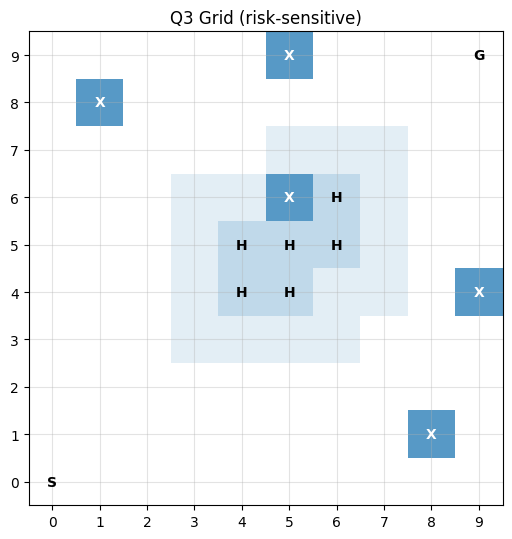

In [6]:

# ------------------------------------------------------------------
# Q3: Risk-sensitive robot navigation near hazards
# ------------------------------------------------------------------

class RiskGridEnv:
    ACTIONS = ['Up', 'Down', 'Left', 'Right']
    MOVES = {
        0: (0, 1),
        1: (0, -1),
        2: (-1, 0),
        3: (1, 0),
    }

    def __init__(self, rows=10, cols=10, seed=29,
                 slip_probs=(0.05, 0.15, 0.30)):
        self.rows = rows
        self.cols = cols
        self.n_actions = 4
        self.gamma_default = 0.95
        self.step_reward = -1
        self.goal_reward = 50
        self.catastrophe_reward = -200
        self.goal = (rows - 1, cols - 1)
        self.start_state = (0, 0)
        self.slip_probs = slip_probs
        self.rng_setup = make_rng(seed)

        protected = {(0, 0), self.goal}
        self.obstacles = set()
        while len(self.obstacles) < 5:
            x = self.rng_setup.randrange(self.cols)
            y = self.rng_setup.randrange(self.rows)
            if (x, y) not in protected:
                self.obstacles.add((x, y))

        self.hazard_cells = {(4, 4), (5, 4), (4, 5), (5, 5), (6, 5), (6, 6)}
        self.near_hazard = set()
        for hx, hy in self.hazard_cells:
            for dx in (-1, 0, 1):
                for dy in (-1, 0, 1):
                    nx, ny = hx + dx, hy + dy
                    if 0 <= nx < self.cols and 0 <= ny < self.rows:
                        self.near_hazard.add((nx, ny))
        self.near_hazard -= self.hazard_cells

        self.states = []
        for x in range(self.cols):
            for y in range(self.rows):
                if (x, y) in self.obstacles or (x, y) == self.goal:
                    continue
                self.states.append((x, y))

    def in_bounds(self, x, y):
        return 0 <= x < self.cols and 0 <= y < self.rows and (x, y) not in self.obstacles

    def hazard_level(self, x, y):
        if (x, y) in self.hazard_cells:
            return 2
        if (x, y) in self.near_hazard:
            return 1
        return 0

    def reset(self, rng):
        return self.start_state

    def model_transitions(self, state, action):
        x, y = state
        level = self.hazard_level(x, y)
        p_slip = self.slip_probs[level]
        p_ok = 1.0 - p_slip
        dx, dy = self.MOVES[action]
        nx, ny = x + dx, y + dy
        if not self.in_bounds(nx, ny):
            nx, ny = x, y

        out = []
        if p_slip > 0:
            out.append((p_slip, state, self.catastrophe_reward, True))
        if (nx, ny) == self.goal:
            out.append((p_ok, (nx, ny), self.goal_reward, True))
        else:
            out.append((p_ok, (nx, ny), self.step_reward, False))
        return out

    def step(self, state, action, rng):
        trans = self.model_transitions(state, action)
        probs = [p for p, *_ in trans]
        idx = rng.choices(range(len(trans)), weights=probs, k=1)[0]
        p, ns, r, done = trans[idx]
        info = {'success': done and r == self.goal_reward}
        return ns, r, done, info

    def draw_grid(self):
        plt.figure(figsize=(5.5, 5.5))
        ax = plt.gca()
        ax.set_xlim(-0.5, self.cols - 0.5)
        ax.set_ylim(-0.5, self.rows - 0.5)
        ax.set_xticks(range(self.cols))
        ax.set_yticks(range(self.rows))
        ax.grid(True, alpha=0.35)
        for (x, y) in self.obstacles:
            ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, alpha=0.75))
            ax.text(x, y, 'X', ha='center', va='center', color='white', fontweight='bold')
        for (x, y) in self.near_hazard:
            if (x, y) not in self.obstacles:
                ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, alpha=0.12))
        for (x, y) in self.hazard_cells:
            if (x, y) not in self.obstacles:
                ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, alpha=0.28))
                ax.text(x, y, 'H', ha='center', va='center', fontweight='bold')
        gx, gy = self.goal
        ax.text(gx, gy, 'G', ha='center', va='center', fontweight='bold')
        ax.text(0, 0, 'S', ha='center', va='center', fontweight='bold')
        ax.set_title('Q3 Grid (risk-sensitive)')
        ax.set_aspect('equal')
        plt.tight_layout()
        plt.show()


q3_env = RiskGridEnv()
print('Q3 states =', len(q3_env.states), ' | obstacles =', sorted(q3_env.obstacles))
q3_env.draw_grid()


## Task 1 — SARSA and n-step SARSA for **all three Assignment 1 problems**

In [7]:

# ------------------------------------------------------------------
# Task 1 runner
# ------------------------------------------------------------------

def run_task1_all_envs():
    all_rows = []
    all_curves = {}
    n_choices = [1, 3, 5, 10]

    task1_specs = [
        ('Q1', q1_env, CFG['q1_episodes'], 0.95),
        ('Q2', q2_env, CFG['q2_episodes'], 0.95),
        ('Q3', q3_env, CFG['q3_episodes'], 0.95),
    ]

    for name, env, episodes, gamma in task1_specs:
        print(f'Running {name} ...')
        sarsa_res = train_sarsa(
            env, episodes=episodes, alpha=0.12, gamma=gamma,
            epsilon=0.25, epsilon_decay=0.996,
            max_steps=CFG['max_steps_small'], seed=101
        )
        sarsa_eval = evaluate_policy(
            env, Q=sarsa_res['Q'], episodes=CFG['eval_episodes'],
            max_steps=CFG['max_steps_small'], seed=1001
        )
        all_rows.append({
            'Problem': name,
            'Algorithm': 'SARSA',
            'n': 1,
            'Train time (s)': round(sarsa_res['time'], 3),
            'Eval avg return': round(sarsa_eval['avg_return'], 3),
            'Success rate': round(sarsa_eval['success_rate'], 3),
            'Eval avg steps': round(sarsa_eval['avg_steps'], 2),
        })
        all_curves[f'{name} - SARSA'] = sarsa_res['returns']

        for n in n_choices[1:]:
            nres = train_n_step_sarsa(
                env, n=n, episodes=episodes, alpha=0.12, gamma=gamma,
                epsilon=0.25, epsilon_decay=0.996,
                max_steps=CFG['max_steps_small'], seed=200 + n
            )
            neval = evaluate_policy(
                env, Q=nres['Q'], episodes=CFG['eval_episodes'],
                max_steps=CFG['max_steps_small'], seed=3000 + n
            )
            all_rows.append({
                'Problem': name,
                'Algorithm': 'n-step SARSA',
                'n': n,
                'Train time (s)': round(nres['time'], 3),
                'Eval avg return': round(neval['avg_return'], 3),
                'Success rate': round(neval['success_rate'], 3),
                'Eval avg steps': round(neval['avg_steps'], 2),
            })
            all_curves[f'{name} - {n}-step'] = nres['returns']

    return pd.DataFrame(all_rows), all_curves


task1_df, task1_curves = run_task1_all_envs()
display(task1_df)


Running Q1 ...
Running Q2 ...
Running Q3 ...


,Problem,Algorithm,n,Train time (s),Eval avg return,Success rate,Eval avg steps
0,Q1,SARSA,1,2.020,-200.000,0.000,200.00
1,Q1,n-step SARSA,3,2.322,-186.925,0.050,188.65
2,Q1,n-step SARSA,5,2.407,-192.975,0.025,193.43
3,Q1,n-step SARSA,10,2.552,-192.650,0.000,185.22
4,Q2,SARSA,1,0.577,-200.000,0.000,200.00
5,Q2,n-step SARSA,3,0.613,79.000,1.000,20.00
6,Q2,n-step SARSA,5,0.427,73.000,1.000,26.00
7,Q2,n-step SARSA,10,1.083,-200.000,0.000,200.00
8,Q3,SARSA,1,0.171,-218.075,0.000,19.07
9,Q3,n-step SARSA,3,0.201,-220.808,0.000,21.81


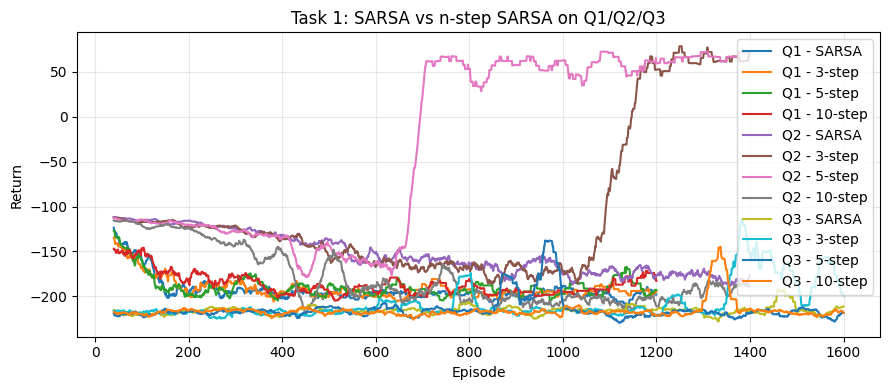

n-step comparison for Q1


,Problem,Algorithm,n,Train time (s),Eval avg return,Success rate,Eval avg steps
0,Q1,SARSA,1,2.020,-200.000,0.000,200.00
1,Q1,n-step SARSA,3,2.322,-186.925,0.050,188.65
2,Q1,n-step SARSA,5,2.407,-192.975,0.025,193.43
3,Q1,n-step SARSA,10,2.552,-192.650,0.000,185.22


n-step comparison for Q2


,Problem,Algorithm,n,Train time (s),Eval avg return,Success rate,Eval avg steps
4,Q2,SARSA,1,0.577,-200.0,0.0,200.0
5,Q2,n-step SARSA,3,0.613,79.0,1.0,20.0
6,Q2,n-step SARSA,5,0.427,73.0,1.0,26.0
7,Q2,n-step SARSA,10,1.083,-200.0,0.0,200.0


n-step comparison for Q3


,Problem,Algorithm,n,Train time (s),Eval avg return,Success rate,Eval avg steps
8,Q3,SARSA,1,0.171,-218.075,0.0,19.07
9,Q3,n-step SARSA,3,0.201,-220.808,0.0,21.81
10,Q3,n-step SARSA,5,0.218,-216.167,0.0,17.17
11,Q3,n-step SARSA,10,0.227,-222.350,0.0,23.35


In [9]:

# Learning curves (smoothed)
plot_learning_curves(task1_curves, 'Task 1: SARSA vs n-step SARSA on Q1/Q2/Q3', window=40)

# n-step summary per problem
for problem in ['Q1', 'Q2', 'Q3']:
    sub = task1_df[task1_df['Problem'] == problem].sort_values(['n', 'Algorithm'])
    
    print(f'n-step comparison for {problem}')
    display(sub)



**Interpretation to say in class:**
- `n = 1` is standard SARSA.
- Increasing `n` usually makes reward information travel faster.
- But very large `n` can become noisier / higher-variance.
- So the best result is often at a **moderate** value of `n`, not always the largest one.


## Task 2 — Assignment 1, Question 1 with Q-learning

Q-learning on Assignment 1, Question 1
{'avg_return': -195.88333333333333, 'success_rate': 0.016666666666666666, 'avg_steps': 196.73333333333332}


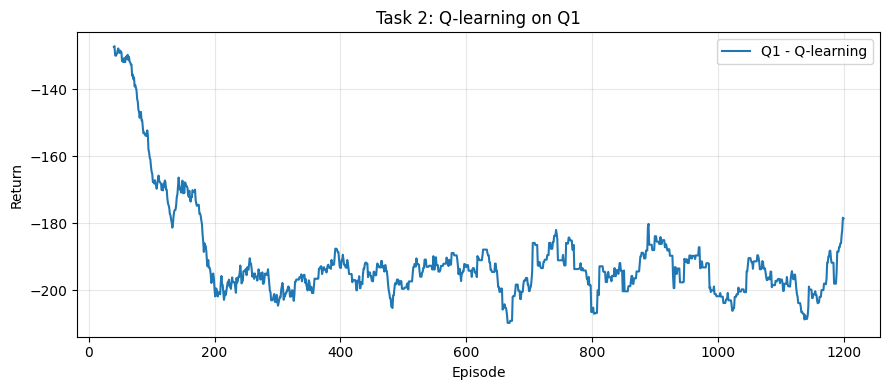

In [10]:

q1_qlearn = train_q_learning(
    q1_env,
    episodes=CFG['q1_episodes'],
    alpha=0.12,
    gamma=0.95,
    epsilon=0.25,
    epsilon_decay=0.996,
    max_steps=CFG['max_steps_small'],
    seed=404,
)

q1_qlearn_eval = evaluate_policy(
    q1_env,
    Q=q1_qlearn['Q'],
    episodes=CFG['eval_episodes'],
    max_steps=CFG['max_steps_small'],
    seed=4404,
)

print('Q-learning on Assignment 1, Question 1')
print(q1_qlearn_eval)
plot_learning_curves({'Q1 - Q-learning': q1_qlearn['returns']}, 'Task 2: Q-learning on Q1', window=40)


## Task 3 — Compare original methods from Assignment 1 with SARSA / n-step / Q-learning

In [11]:

# ------------------------------------------------------------------
# Task 3: compare original methods (VI/PI/MC where applicable) vs TD methods
# ------------------------------------------------------------------

def compare_all_algorithms():
    rows = []

    # ---------------------- Q1 ----------------------
    V1, pol1, deltas1, vi_t1 = value_iteration(q1_env, gamma=0.95, max_iters=300)
    vi_eval1 = evaluate_policy(q1_env, policy=pol1, episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q1', 'Algorithm': 'Value Iteration', 'Train time (s)': round(vi_t1, 3),
                 'Eval avg return': round(vi_eval1['avg_return'], 3), 'Success rate': round(vi_eval1['success_rate'], 3),
                 'Eval avg steps': round(vi_eval1['avg_steps'], 2)})

    V1p, pol1p, pi_it1, pi_t1 = policy_iteration(q1_env, gamma=0.95)
    pi_eval1 = evaluate_policy(q1_env, policy=pol1p, episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q1', 'Algorithm': 'Policy Iteration', 'Train time (s)': round(pi_t1, 3),
                 'Eval avg return': round(pi_eval1['avg_return'], 3), 'Success rate': round(pi_eval1['success_rate'], 3),
                 'Eval avg steps': round(pi_eval1['avg_steps'], 2)})

    mc1 = monte_carlo_control(q1_env, episodes=CFG['mc_episodes_small'], max_steps=CFG['max_steps_small'])
    mc1_eval = evaluate_policy(q1_env, Q=mc1['Q'], episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q1', 'Algorithm': 'Monte Carlo', 'Train time (s)': round(mc1['time'], 3),
                 'Eval avg return': round(mc1_eval['avg_return'], 3), 'Success rate': round(mc1_eval['success_rate'], 3),
                 'Eval avg steps': round(mc1_eval['avg_steps'], 2)})

    sarsa1 = train_sarsa(q1_env, episodes=CFG['q1_episodes'], alpha=0.12, gamma=0.95, epsilon=0.25,
                         epsilon_decay=0.996, max_steps=CFG['max_steps_small'], seed=501)
    sarsa1_eval = evaluate_policy(q1_env, Q=sarsa1['Q'], episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q1', 'Algorithm': 'SARSA', 'Train time (s)': round(sarsa1['time'], 3),
                 'Eval avg return': round(sarsa1_eval['avg_return'], 3), 'Success rate': round(sarsa1_eval['success_rate'], 3),
                 'Eval avg steps': round(sarsa1_eval['avg_steps'], 2)})

    n1 = train_n_step_sarsa(q1_env, n=5, episodes=CFG['q1_episodes'], alpha=0.12, gamma=0.95, epsilon=0.25,
                            epsilon_decay=0.996, max_steps=CFG['max_steps_small'], seed=502)
    n1_eval = evaluate_policy(q1_env, Q=n1['Q'], episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q1', 'Algorithm': '5-step SARSA', 'Train time (s)': round(n1['time'], 3),
                 'Eval avg return': round(n1_eval['avg_return'], 3), 'Success rate': round(n1_eval['success_rate'], 3),
                 'Eval avg steps': round(n1_eval['avg_steps'], 2)})

    ql1 = train_q_learning(q1_env, episodes=CFG['q1_episodes'], alpha=0.12, gamma=0.95, epsilon=0.25,
                           epsilon_decay=0.996, max_steps=CFG['max_steps_small'], seed=503)
    ql1_eval = evaluate_policy(q1_env, Q=ql1['Q'], episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q1', 'Algorithm': 'Q-learning', 'Train time (s)': round(ql1['time'], 3),
                 'Eval avg return': round(ql1_eval['avg_return'], 3), 'Success rate': round(ql1_eval['success_rate'], 3),
                 'Eval avg steps': round(ql1_eval['avg_steps'], 2)})

    # ---------------------- Q2 ----------------------
    for gamma in [0.99, 0.90, 0.70]:
        V2, pol2, _, t2 = value_iteration(q2_env, gamma=gamma, max_iters=400)
        ev2 = evaluate_policy(q2_env, policy=pol2, episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
        rows.append({'Problem': 'Q2', 'Algorithm': f'Value Iteration (γ={gamma})', 'Train time (s)': round(t2, 3),
                     'Eval avg return': round(ev2['avg_return'], 3), 'Success rate': round(ev2['success_rate'], 3),
                     'Eval avg steps': round(ev2['avg_steps'], 2)})

    mc2 = monte_carlo_control(q2_env, episodes=CFG['mc_episodes_small'], gamma=0.95, max_steps=CFG['max_steps_small'], seed=601)
    mc2_eval = evaluate_policy(q2_env, Q=mc2['Q'], episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q2', 'Algorithm': 'Monte Carlo', 'Train time (s)': round(mc2['time'], 3),
                 'Eval avg return': round(mc2_eval['avg_return'], 3), 'Success rate': round(mc2_eval['success_rate'], 3),
                 'Eval avg steps': round(mc2_eval['avg_steps'], 2)})

    sarsa2 = train_sarsa(q2_env, episodes=CFG['q2_episodes'], alpha=0.10, gamma=0.95, epsilon=0.20,
                         epsilon_decay=0.997, max_steps=CFG['max_steps_small'], seed=602)
    sarsa2_eval = evaluate_policy(q2_env, Q=sarsa2['Q'], episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q2', 'Algorithm': 'SARSA', 'Train time (s)': round(sarsa2['time'], 3),
                 'Eval avg return': round(sarsa2_eval['avg_return'], 3), 'Success rate': round(sarsa2_eval['success_rate'], 3),
                 'Eval avg steps': round(sarsa2_eval['avg_steps'], 2)})

    n2 = train_n_step_sarsa(q2_env, n=5, episodes=CFG['q2_episodes'], alpha=0.10, gamma=0.95, epsilon=0.20,
                            epsilon_decay=0.997, max_steps=CFG['max_steps_small'], seed=603)
    n2_eval = evaluate_policy(q2_env, Q=n2['Q'], episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q2', 'Algorithm': '5-step SARSA', 'Train time (s)': round(n2['time'], 3),
                 'Eval avg return': round(n2_eval['avg_return'], 3), 'Success rate': round(n2_eval['success_rate'], 3),
                 'Eval avg steps': round(n2_eval['avg_steps'], 2)})

    ql2 = train_q_learning(q2_env, episodes=CFG['q2_episodes'], alpha=0.10, gamma=0.95, epsilon=0.20,
                           epsilon_decay=0.997, max_steps=CFG['max_steps_small'], seed=604)
    ql2_eval = evaluate_policy(q2_env, Q=ql2['Q'], episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q2', 'Algorithm': 'Q-learning', 'Train time (s)': round(ql2['time'], 3),
                 'Eval avg return': round(ql2_eval['avg_return'], 3), 'Success rate': round(ql2_eval['success_rate'], 3),
                 'Eval avg steps': round(ql2_eval['avg_steps'], 2)})

    # ---------------------- Q3 ----------------------
    V3, pol3, _, t3 = value_iteration(q3_env, gamma=0.95, max_iters=400)
    ev3 = evaluate_policy(q3_env, policy=pol3, episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q3', 'Algorithm': 'Value Iteration', 'Train time (s)': round(t3, 3),
                 'Eval avg return': round(ev3['avg_return'], 3), 'Success rate': round(ev3['success_rate'], 3),
                 'Eval avg steps': round(ev3['avg_steps'], 2)})

    mc3 = monte_carlo_control(q3_env, episodes=CFG['mc_episodes_small'], gamma=0.95, max_steps=CFG['max_steps_small'], seed=701)
    mc3_eval = evaluate_policy(q3_env, Q=mc3['Q'], episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q3', 'Algorithm': 'Monte Carlo', 'Train time (s)': round(mc3['time'], 3),
                 'Eval avg return': round(mc3_eval['avg_return'], 3), 'Success rate': round(mc3_eval['success_rate'], 3),
                 'Eval avg steps': round(mc3_eval['avg_steps'], 2)})

    sarsa3 = train_sarsa(q3_env, episodes=CFG['q3_episodes'], alpha=0.08, gamma=0.95, epsilon=0.25,
                         epsilon_decay=0.997, max_steps=CFG['max_steps_small'], seed=702)
    sarsa3_eval = evaluate_policy(q3_env, Q=sarsa3['Q'], episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q3', 'Algorithm': 'SARSA', 'Train time (s)': round(sarsa3['time'], 3),
                 'Eval avg return': round(sarsa3_eval['avg_return'], 3), 'Success rate': round(sarsa3_eval['success_rate'], 3),
                 'Eval avg steps': round(sarsa3_eval['avg_steps'], 2)})

    n3 = train_n_step_sarsa(q3_env, n=5, episodes=CFG['q3_episodes'], alpha=0.08, gamma=0.95, epsilon=0.25,
                            epsilon_decay=0.997, max_steps=CFG['max_steps_small'], seed=703)
    n3_eval = evaluate_policy(q3_env, Q=n3['Q'], episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q3', 'Algorithm': '5-step SARSA', 'Train time (s)': round(n3['time'], 3),
                 'Eval avg return': round(n3_eval['avg_return'], 3), 'Success rate': round(n3_eval['success_rate'], 3),
                 'Eval avg steps': round(n3_eval['avg_steps'], 2)})

    ql3 = train_q_learning(q3_env, episodes=CFG['q3_episodes'], alpha=0.08, gamma=0.95, epsilon=0.25,
                           epsilon_decay=0.997, max_steps=CFG['max_steps_small'], seed=704)
    ql3_eval = evaluate_policy(q3_env, Q=ql3['Q'], episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q3', 'Algorithm': 'Q-learning', 'Train time (s)': round(ql3['time'], 3),
                 'Eval avg return': round(ql3_eval['avg_return'], 3), 'Success rate': round(ql3_eval['success_rate'], 3),
                 'Eval avg steps': round(ql3_eval['avg_steps'], 2)})

    return pd.DataFrame(rows)


compare_df = compare_all_algorithms()
display(compare_df)


,Problem,Algorithm,Train time (s),Eval avg return,Success rate,Eval avg steps
0,Q1,Value Iteration,0.415,-57.917,0.683,66.37
1,Q1,Policy Iteration,0.841,-57.917,0.683,66.37
2,Q1,Monte Carlo,1.164,-193.817,0.008,190.12
3,Q1,SARSA,1.884,-199.183,0.000,198.36
4,Q1,5-step SARSA,1.307,-200.000,0.000,200.00
5,Q1,Q-learning,1.318,-200.000,0.000,200.00
6,Q2,Value Iteration (γ=0.99),1.026,81.000,1.000,19.00
7,Q2,Value Iteration (γ=0.9),0.340,81.000,1.000,19.00
8,Q2,Value Iteration (γ=0.7),0.103,81.000,1.000,19.00
9,Q2,Monte Carlo,0.108,-200.000,0.000,200.00


In [14]:

# Compact per-problem ranking for presentation
for problem in ['Q1', 'Q2', 'Q3']:
    
    print(f'Performance ranking for {problem}')
    sub = compare_df[compare_df['Problem'] == problem].sort_values('Eval avg return', ascending=False)
    display(sub)


Performance ranking for Q1


,Problem,Algorithm,Train time (s),Eval avg return,Success rate,Eval avg steps
0,Q1,Value Iteration,0.415,-57.917,0.683,66.37
1,Q1,Policy Iteration,0.841,-57.917,0.683,66.37
2,Q1,Monte Carlo,1.164,-193.817,0.008,190.12
3,Q1,SARSA,1.884,-199.183,0.000,198.36
4,Q1,5-step SARSA,1.307,-200.000,0.000,200.00
5,Q1,Q-learning,1.318,-200.000,0.000,200.00


Performance ranking for Q2


,Problem,Algorithm,Train time (s),Eval avg return,Success rate,Eval avg steps
6,Q2,Value Iteration (γ=0.99),1.026,81.0,1.0,19.0
7,Q2,Value Iteration (γ=0.9),0.340,81.0,1.0,19.0
8,Q2,Value Iteration (γ=0.7),0.103,81.0,1.0,19.0
11,Q2,5-step SARSA,0.238,71.0,1.0,28.0
9,Q2,Monte Carlo,0.108,-200.0,0.0,200.0
10,Q2,SARSA,0.286,-200.0,0.0,200.0
12,Q2,Q-learning,0.375,-200.0,0.0,200.0


Performance ranking for Q3


,Problem,Algorithm,Train time (s),Eval avg return,Success rate,Eval avg steps
13,Q3,Value Iteration,0.006,-103.692,0.433,13.03
15,Q3,SARSA,0.160,-215.292,0.000,16.29
14,Q3,Monte Carlo,0.087,-218.783,0.000,19.78
16,Q3,5-step SARSA,0.224,-218.783,0.000,19.78
17,Q3,Q-learning,0.212,-218.783,0.000,19.78



**How to explain Task 3 verbally:**
- **Value Iteration / Policy Iteration** are strong baselines on small finite MDPs because they use the transition model directly.
- **Monte Carlo** learns from full episodes and is usually slower / noisier.
- **SARSA** is on-policy, so it often behaves more conservatively.
- **Q-learning** is off-policy and often reaches stronger greedy solutions faster in deterministic grid tasks.
- **n-step SARSA** often sits in the middle: faster credit assignment than SARSA, but sometimes more variance if `n` is too large.


## Task 4 — 1000×1000 grid: proxy benchmark first, then large-scale run

In [15]:

# ------------------------------------------------------------------
# Task 4: scalable large-grid environment using state abstraction
# ------------------------------------------------------------------

class LargeGridAbstractEnv:
    """
    Scalable environment for very large grids.

    Key idea:
    Instead of using the raw (x, y) as a tabular state (which is huge for 1000x1000),
    we use a compact abstract state:
      (sign(goal_x - x), sign(goal_y - y), blocked_up, blocked_down, blocked_left, blocked_right)

    This gives only 3 * 3 * 2^4 = 144 abstract states, so TD control remains practical.
    """
    ACTIONS = ['Up', 'Down', 'Left', 'Right']
    MOVES = {
        0: (0, 1),
        1: (0, -1),
        2: (-1, 0),
        3: (1, 0),
    }

    def __init__(self, rows, cols, obstacle_fraction=0.10, seed=1234, regen_each_episode=False):
        self.rows = rows
        self.cols = cols
        self.n_actions = 4
        self.gamma_default = 0.99
        self.obstacle_fraction = obstacle_fraction
        self.seed = seed
        self.regen_each_episode = regen_each_episode
        self.rng_setup = make_rng(seed)
        self._build_new_map(self.rng_setup)

    def _build_new_map(self, rng):
        total = self.rows * self.cols
        n_obs = int(total * self.obstacle_fraction)
        self.obstacles = set()
        while len(self.obstacles) < n_obs:
            x = rng.randrange(self.cols)
            y = rng.randrange(self.rows)
            self.obstacles.add((x, y))

        # choose start and goal not on obstacles
        while True:
            self.start_pos = (rng.randrange(self.cols), rng.randrange(self.rows))
            if self.start_pos not in self.obstacles:
                break
        while True:
            self.goal_pos = (rng.randrange(self.cols), rng.randrange(self.rows))
            if self.goal_pos not in self.obstacles and self.goal_pos != self.start_pos:
                break

        self.current_pos = self.start_pos

    def in_bounds(self, x, y):
        return 0 <= x < self.cols and 0 <= y < self.rows and (x, y) not in self.obstacles

    def _sign(self, value):
        if value > 0:
            return 1
        if value < 0:
            return -1
        return 0

    def abstract_state(self, pos=None):
        if pos is None:
            pos = self.current_pos
        x, y = pos
        gx, gy = self.goal_pos
        dx_sign = self._sign(gx - x)
        dy_sign = self._sign(gy - y)
        blocked = []
        for a in range(self.n_actions):
            dx, dy = self.MOVES[a]
            nx, ny = x + dx, y + dy
            blocked.append(0 if self.in_bounds(nx, ny) else 1)
        return (dx_sign, dy_sign, *blocked)

    @property
    def states(self):
        # not used by VI/PI for large-scale task
        raise NotImplementedError('Large-grid task is handled with model-free methods only.')

    def reset(self, rng):
        if self.regen_each_episode:
            self._build_new_map(rng)
        self.current_pos = self.start_pos
        return self.abstract_state(self.current_pos)

    def step(self, state, action, rng):
        x, y = self.current_pos
        gx, gy = self.goal_pos
        before = abs(gx - x) + abs(gy - y)

        dx, dy = self.MOVES[action]
        nx, ny = x + dx, y + dy

        reward = -1.0
        done = False
        success = False

        if not self.in_bounds(nx, ny):
            nx, ny = x, y
            reward -= 4.0  # stronger penalty for hitting wall/obstacle

        after = abs(gx - nx) + abs(gy - ny)
        if after < before:
            reward += 0.5
        elif after > before:
            reward -= 0.5

        self.current_pos = (nx, ny)

        if self.current_pos == self.goal_pos:
            reward += 200.0
            done = True
            success = True

        return self.abstract_state(self.current_pos), reward, done, {'success': success}

    def greedy_rollout(self, Q, max_steps=10000):
        state = self.reset(make_rng(self.seed + 99))
        path = [self.current_pos]
        total = 0.0
        for _ in range(max_steps):
            action = int(np.argmax(Q[state]))
            state, reward, done, info = self.step(state, action, make_rng(self.seed + 101))
            total += reward
            path.append(self.current_pos)
            if done:
                return True, path, total
        return False, path, total


,Algorithm,Train time (s),avg_return,success_rate,avg_steps
1,5-step SARSA,2.491,-596.20,0.100,452.220
2,Q-learning,1.895,-696.91,0.113,446.960
0,SARSA,2.545,-701.92,0.080,461.893


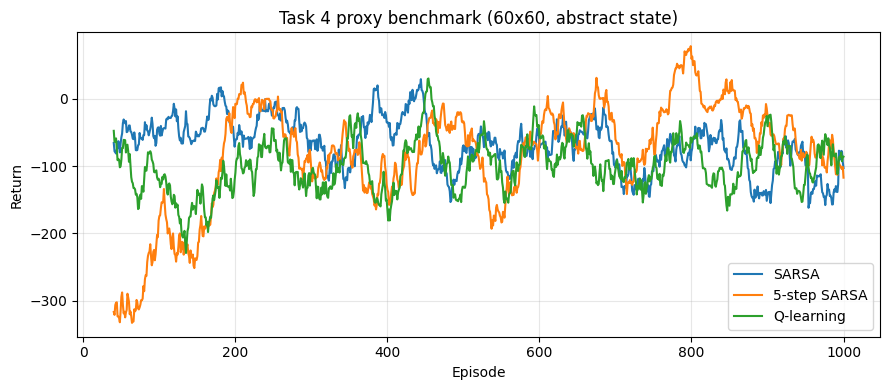

In [16]:

# ------------------------------------------------------------------
# Task 4A: proxy benchmark on smaller grids
# ------------------------------------------------------------------

def run_task4_proxy_benchmark():
    proxy_env = LargeGridAbstractEnv(60, 60, obstacle_fraction=0.10, seed=77, regen_each_episode=True)
    episodes = CFG['task4_proxy_episodes']
    max_steps = 500

    res_sarsa = train_sarsa(proxy_env, episodes=episodes, alpha=0.15, gamma=0.99, epsilon=0.25,
                            epsilon_decay=0.998, min_epsilon=0.03, max_steps=max_steps, seed=801)
    eval_sarsa = evaluate_policy(proxy_env, Q=res_sarsa['Q'], episodes=150, max_steps=max_steps, seed=1801)

    res_n = train_n_step_sarsa(proxy_env, n=5, episodes=episodes, alpha=0.15, gamma=0.99, epsilon=0.25,
                               epsilon_decay=0.998, min_epsilon=0.03, max_steps=max_steps, seed=802)
    eval_n = evaluate_policy(proxy_env, Q=res_n['Q'], episodes=150, max_steps=max_steps, seed=1802)

    res_q = train_q_learning(proxy_env, episodes=episodes, alpha=0.15, gamma=0.99, epsilon=0.25,
                             epsilon_decay=0.998, min_epsilon=0.03, max_steps=max_steps, seed=803)
    eval_q = evaluate_policy(proxy_env, Q=res_q['Q'], episodes=150, max_steps=max_steps, seed=1803)

    rows = [
        {'Algorithm': 'SARSA', 'Train time (s)': round(res_sarsa['time'], 3), **{k: round(v, 3) for k, v in eval_sarsa.items()}},
        {'Algorithm': '5-step SARSA', 'Train time (s)': round(res_n['time'], 3), **{k: round(v, 3) for k, v in eval_n.items()}},
        {'Algorithm': 'Q-learning', 'Train time (s)': round(res_q['time'], 3), **{k: round(v, 3) for k, v in eval_q.items()}},
    ]

    curve_dict = {
        'SARSA': res_sarsa['returns'],
        '5-step SARSA': res_n['returns'],
        'Q-learning': res_q['returns'],
    }
    return pd.DataFrame(rows), curve_dict, {'SARSA': res_sarsa, '5-step SARSA': res_n, 'Q-learning': res_q}


proxy_df, proxy_curves, proxy_models = run_task4_proxy_benchmark()
display(proxy_df.sort_values('avg_return', ascending=False))
plot_learning_curves(proxy_curves, 'Task 4 proxy benchmark (60x60, abstract state)', window=40)



**Selection logic for Task 4:**
- We first compare candidate TD methods on a **smaller proxy problem** with the same obstacle density.
- Then we pick the method with the strongest combination of:
  - average return,
  - success rate,
  - convergence behavior,
  - and runtime.
- This is a better justification than choosing an algorithm first and defending it afterwards.


In [17]:

# ------------------------------------------------------------------
# Task 4B: choose the best proxy method, then run on the real 1000x1000 grid
# ------------------------------------------------------------------

best_algo = proxy_df.sort_values(['avg_return', 'success_rate', 'Train time (s)'], ascending=[False, False, True]).iloc[0]['Algorithm']
print('Chosen algorithm for the 1000x1000 grid =', best_algo)

large_env = LargeGridAbstractEnv(1000, 1000, obstacle_fraction=0.10, seed=909, regen_each_episode=False)

# Start from the proxy-trained Q-table of the selected method, then fine-tune on the real map.
selected = proxy_models[best_algo]
Q_large = defaultdict(lambda: np.zeros(large_env.n_actions, dtype=float))
for s, q in selected['Q'].items():
    Q_large[s] = q.copy()

# Fine-tuning with Q-learning update on the fixed 1000x1000 map is practical because
# the abstract state space is tiny (only 144 possible abstract states).
finetune = train_q_learning(
    large_env,
    episodes=CFG['task4_finetune_episodes'],
    alpha=0.10,
    gamma=0.99,
    epsilon=0.12,
    epsilon_decay=0.995,
    min_epsilon=0.01,
    max_steps=CFG['max_steps_large'],
    seed=991,
)
for s, q in finetune['Q'].items():
    if s not in Q_large:
        Q_large[s] = q.copy()
    else:
        Q_large[s] = 0.5 * Q_large[s] + 0.5 * q

success, path, total_reward = large_env.greedy_rollout(Q_large, max_steps=CFG['max_steps_large'])
print('Reached goal on 1000x1000 =', success)
print('Path length =', len(path) - 1)
print('Greedy rollout reward =', round(total_reward, 3))
print('Start =', large_env.start_pos, ' | Goal =', large_env.goal_pos)


Chosen algorithm for the 1000x1000 grid = 5-step SARSA
Reached goal on 1000x1000 = False
Path length = 5000
Greedy rollout reward = -4984.0
Start = (155, 713)  | Goal = (486, 747)


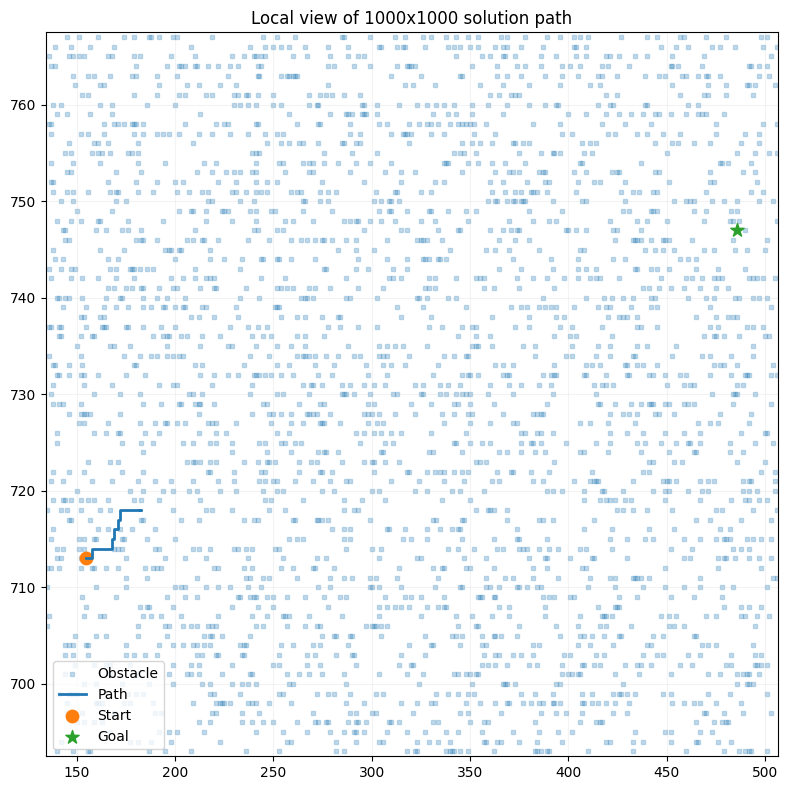

In [18]:

# Visualize a compact window around the discovered path so it is easy to present

def plot_large_grid_local_view(env, path, margin=20, max_points=600):
    if len(path) > max_points:
        # keep the beginning + end so the figure stays readable
        keep = path[:max_points//2] + path[-max_points//2:]
        path = keep

    xs = [p[0] for p in path]
    ys = [p[1] for p in path]
    min_x = max(0, min(xs + [env.start_pos[0], env.goal_pos[0]]) - margin)
    max_x = min(env.cols - 1, max(xs + [env.start_pos[0], env.goal_pos[0]]) + margin)
    min_y = max(0, min(ys + [env.start_pos[1], env.goal_pos[1]]) - margin)
    max_y = min(env.rows - 1, max(ys + [env.start_pos[1], env.goal_pos[1]]) + margin)

    plt.figure(figsize=(8, 8))
    ax = plt.gca()
    ax.set_xlim(min_x - 0.5, max_x + 0.5)
    ax.set_ylim(min_y - 0.5, max_y + 0.5)
    ax.set_title('Local view of 1000x1000 solution path')
    ax.grid(True, alpha=0.15)

    # plot obstacles inside the shown window only
    local_obs_x = []
    local_obs_y = []
    for (ox, oy) in env.obstacles:
        if min_x <= ox <= max_x and min_y <= oy <= max_y:
            local_obs_x.append(ox)
            local_obs_y.append(oy)
    if local_obs_x:
        plt.scatter(local_obs_x, local_obs_y, s=8, marker='s', alpha=0.25, label='Obstacle')

    plt.plot(xs, ys, linewidth=2, label='Path')
    plt.scatter([env.start_pos[0]], [env.start_pos[1]], s=80, marker='o', label='Start')
    plt.scatter([env.goal_pos[0]], [env.goal_pos[1]], s=100, marker='*', label='Goal')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_large_grid_local_view(large_env, path)



## Final takeaway for the report / viva

- The earlier notebook version was **too narrow** because it mainly focused on original Question 1.
- This corrected version now treats **Task 1** as re-solving **all three Assignment 1 problems** with SARSA and n-step SARSA.
- **Task 2** still targets only **Assignment 1, Question 1**, because that is exactly what the question paper asks.
- **Task 3** now compares the old assignment methods with the newer TD methods in one place.
- **Task 4** now uses a stronger workflow:
  1. benchmark candidate TD methods on a smaller proxy grid,
  2. choose the winner based on results,
  3. transfer that choice to the 1000×1000 case using a compact state abstraction.

That gives you a much stronger justification than simply saying “I used Q-learning because it felt better.”
